# Обучение модели по предсказанию массы морских черепах



Разработать надёжную модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.

## Постановка задачи машинного обучения

Необходимо обучить несколько линейных моделей и выбрать лучшую для прогрозирования массы морских черепах.
- Целевой переменной будет выступать `масса черепахи`

Метрики выбора модели:
- MAE, должна быть не более 5 кг.
- R2 не меньше 0.97
- Дополнительно проверить MAPE, для оценки предсказания черепах разного размера/возраста 

В тестовой выборке должно быть не меньше 20% от датасета.
Для воспроизводимости указать random_state

По результатам моделирования необходимо написать функцию предсказания массы черепахи по её признакам, используя формулу линейной регрессии.


## Подключение и настройка библиотек

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

In [2]:
## Перед отправкой ревьюверу - поменять путь
df = pd.read_csv("../data/turtles.csv", sep='\t', decimal=',')

## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

### Ожидаемые данные

- `id` — идентификатор измерения.
- `binomial_name` — международное научное название вида черепахи.
- `registration_number` — регистрационный номер черепахи.
- `shell_length` — длина панциря, мм.
- `shell_width` — ширина панциря, мм.
- `head_length` — длина головы, мм.
- `head_width` — ширина головы, мм.
- `flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- `flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
- `circle_count` — количество колец роста на панцире черепахи.
- `measure_count` — количество измерений, которые произвели, прежде чем усреднить показатели черепахи и добавить их в таблицу.
- `shell_crack` — наличие трещин панциря.
- `timestamp` — время внесения данных о черепахе.
- `weight` — масса черепахи, кг.

In [3]:
df.sample(10, random_state=42)

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
6282,18472,Chelonia mydas,72225e27192766a640c14c94949c5d4d,1466.0,1300,289.0,196.0,927,786,721,775,623.0,590.0,601.0,569.0,97,2.0,3.0,1683156827,166.651
6516,20464,lepidochelys olivacea,8def87260ed8fd5c3e96b1f3ede23ffe,391.0,298,63.0,57.0,268,222,322,160,212.0,152.0,218.0,150.0,0,3.0,NaN,1703512227,28.212
5953,20025,Lepidochelys olivacea,f7149469c2a61ee615ecc4f93b955524,357.0,243,48.0,45.0,287,197,274,184,187.0,167.0,196.0,154.0,0,4.0,1.0,1699438150,26.959
4891,23408,Lepidochelys olivacea,8462bc874482be87d1d93c424d413f00,537.0,425,73.0,84.0,379,311,347,327,292.0,302.0,253.0,234.0,6,1.0,NaN,1733925092,35.606
222,18062,Lepidochelys olivacea,ab7fd8cd0531b738d45294cc500b7c0a,376.0,296,63.0,62.0,245,195,281,253,240.0,160.0,255.0,183.0,0,4.0,NaN,1678971889,28.793
3859,21683,Lepidochelys olivacea,9e6054bc27a3777824e76eaa3e1e9532,481.0,412,83.0,90.0,317,277,316,284,249.0,242.0,321.0,213.0,0,2.0,NaN,1716252218,34.603
4011,20096,Chelonia mydas,9bc3f30a4e18fea07cbb83b859d11489,982.0,942,131.0,183.0,608,513,670,440,425.0,343.0,460.0,413.0,71,1.0,NaN,1699870235,80.109
4896,17465,lepidochelys olivacea,9333a76b4b9b87e7627c0c686bc40590,466.0,357,73.0,66.0,327,250,292,229,255.0,197.0,225.0,181.0,0,4.0,NaN,1672823871,31.459
2199,20912,Lepidochelys olivacea,35240166b09268a952662df3126d49b0,514.0,402,88.0,91.0,372,348,386,340,318.0,237.0,259.0,248.0,3,1.0,NaN,1708065501,33.737
6518,23707,Caretta caretta,b632974e242028d4dd76273b07a8fd88,168.0,91,27.0,17.0,84,47,82,48,66.0,43.0,72.0,37.0,15,2.0,NaN,1736701270,16.957


In [4]:
## Размер датасета
df.shape

(8861, 20)

In [5]:
## Посмотрим на формат данных
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

Название колонки `registration_number` в датасете представлено как `registration number`, стоит переименовать

In [6]:
# Переименование через словарь
df = df.rename(columns={'registration number': 'registration_number'})

**Промежуточные выводы**

В данных найдены пропуски. Подробнее будут исследованы в предобработке данных.

Общий размер данных: 8861 наблюдений

Колонка `registration number` переименована в `registration_number`, чтобы соответствовать ожидаемым данных и общему принципу наименования

## Создание нового DF только с нужным нам видом черепах "Chelonia mydas"

Оценим уникальные значения в `binomial_name`

In [7]:
## Вывод уникальных значений категориальных данных
for column in ['binomial_name']: 
	unique_vals = df[column].sort_values().unique() 
	print(f'Столбец "{column}" — {len(unique_vals)} уникальных значений:') 
	print(', '.join(map(str, unique_vals))) 
	print()

Столбец "binomial_name" — 24 уникальных значений:
CARETTA CARETTA, CHELONIA MYDAS, Caretta Caretta, Caretta caretta, Chelonia Mydas, Chelonia mydas, DERMOCHELYS CORIACEA, Dermochelys Coriacea, Dermochelys coriacea, ERETMOCHELYS IMBRICATA, Eretmochelys Imbricata, Eretmochelys imbricata, LEPIDOCHELYS OLIVACEA, Lepidochelys Kempii, Lepidochelys Olivacea, Lepidochelys kempii, Lepidochelys olivacea, caretta caretta, chelonia mydas, dermochelys coriacea, eretmochelys imbricata, lepidochelys kempii, lepidochelys olivacea, nan



Видно, что значения категорий повторяются в разных регистрах.

Нужно привести все к одному регистру и поискать дубликаты

In [8]:
def lowercase_categories(df, columns):
    for col in columns:
        # Проверяем, является ли колонка строковой (object или string)
        if pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].str.lower()
    return df

# Применение:
df = lowercase_categories(df, ['binomial_name'])
df.head()

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,lepidochelys olivacea,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,lepidochelys olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


Теперь оставим только черепах `сhelonia mydas`

In [9]:
df = df.loc[df['binomial_name'] == 'chelonia mydas']
df.shape

(2829, 20)

**Промежуточный вывод**

После приведения названий видов к нижнему регистру и фильтрации по нужному нам.
Датасет составляет 2829 налюдений

### Проверка дубликатов

In [10]:
# Проверка явных дубликатов
df.duplicated().sum()

np.int64(341)

In [11]:
# колонки, которые могут быть дубликатами
dublicate_cols = ['binomial_name', 'registration_number']
# keep=False — помечает ВСЕ строки (и оригинал и дубликат)
print("Найдено неявных дубликатов:")
df.duplicated(subset=dublicate_cols, keep=False).sum()

Найдено неявных дубликатов:


np.int64(686)

In [12]:
# keep=False — помечает ВСЕ строки (и оригинал и дубликат)
all_dups = df[df.duplicated(subset=dublicate_cols, keep=False)]
all_dups.sort_values(by=dublicate_cols)

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
7679,24052,chelonia mydas,0084bcde2ee31ab0b1b3c54ddcbd5d98,868.0,768,117.0,128.0,521,489,512,470,411.0,335.0,412.0,387.0,80,3.0,NaN,1739883599,67.120
8698,24052,chelonia mydas,0084bcde2ee31ab0b1b3c54ddcbd5d98,868.0,768,117.0,128.0,521,489,512,470,411.0,335.0,412.0,387.0,80,3.0,NaN,1739883599,67.120
7818,24549,chelonia mydas,01ae1863c0868d98c7ec3af168c04ffa,875.0,781,186.0,153.0,473,520,573,479,370.0,355.0,433.0,351.0,100,3.0,NaN,1744516144,69.363
8837,24549,chelonia mydas,01ae1863c0868d98c7ec3af168c04ffa,875.0,781,186.0,153.0,473,520,573,479,370.0,355.0,433.0,351.0,100,3.0,NaN,1744516144,69.363
7574,18249,chelonia mydas,01f72667b3f84ad1bb4c95591f54ce82,1235.0,1074,171.0,230.0,687,733,741,719,574.0,523.0,546.0,526.0,80,1.0,NaN,1680693873,121.503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8038,24330,chelonia mydas,ffea4045eb77613697d0cb118f2d3495,1081.0,981,134.0,145.0,658,563,662,508,516.0,473.0,493.0,493.0,81,3.0,NaN,1742575306,92.350
507,24655,chelonia mydas,NaN,849.0,844,111.0,148.0,569,416,531,407,438.0,391.0,453.0,378.0,65,4.0,NaN,1745486617,72.644
1329,18763,chelonia mydas,NaN,1067.0,975,153.0,151.0,681,561,686,508,489.0,447.0,498.0,393.0,84,3.0,1.0,1686190633,102.462
2761,22599,chelonia mydas,NaN,1471.0,1167,259.0,229.0,930,703,807,785,663.0,581.0,624.0,653.0,134,3.0,NaN,1725428699,166.148


**Промежуточный вывод**

Неявных дубликатов не найдено. Есть 3 значения, но у них `registration_number` NaN, все остальные значения различаются, поэтому это вряд ли дубликаты

### Удаление колонок, которые не являются признаками

Из данных можно удалить неоторые столюцы, которые не являются признаками черепахи:

- `id` - индекс записи
- `binomial_name` - у нас только один binomial_name, и в данные мы должны передать числа.
- `registration_number` - уникальный номер черепахи, не относится к ее размеру/возасту и т.д
- `measure_count` - количество измерений, скорее свидетельствуют о точности данных по черепахе
- `timestamp` - время измерения, относится к измерению, но не к характеристикам черепахи

In [13]:
df = df.drop(columns=['id', 'binomial_name', 'registration_number', 'timestamp', 'measure_count'])

### Предобработка количественных данных

Видны пропуски, нужно посчитать их отдельно. Также много float64 - Это может говорить, что в ячейках есть NaN

In [14]:
# Запоминаем числовые ячейки
num_cols = ['shell_length', 'shell_width', 'head_length', 'flipper_length_1', 'flipper_length_2', 'flipper_length_3', 'flipper_length_4', 'flipper_width_1', 'flipper_width_2', 'flipper_width_3', 'flipper_width_4', 'circle_count', 'shell_crack', 'weight']

In [15]:
## Запоминаем сколько всего в df строк
start_df_size = df.shape[0]

In [16]:
# Вывод доли пропусков
empty = df[num_cols].isna().mean() * 100
# Вывод только колонок где пропуски есть
empty.loc[empty > 0]

shell_length         1.237186
head_length          1.378579
flipper_length_3     1.095794
flipper_length_4     1.095794
flipper_width_3      1.095794
flipper_width_4      1.095794
shell_crack         76.069282
weight               0.106045
dtype: float64

**Пропуски**

Видно, что пропуски есть во многих ячейках, но не более 1,5%

Единственная большая доля пропусков в shell_crack. Стоит проанализировать - пропуск в ней означает, что нет трещин или что-то другое.

In [17]:
# Проверим значения в количественных колонках
for column in num_cols:
    print(f'Значения в {column}:')
    print(df[column].describe())
    print()

Значения в shell_length:
count     2794.000000
mean      1052.253758
std        582.266941
min        645.000000
25%        837.000000
50%        978.500000
75%       1177.750000
max      12840.000000
Name: shell_length, dtype: float64

Значения в shell_width:
count     2829.000000
mean       948.835277
std        519.814403
min        564.000000
25%        753.000000
50%        889.000000
75%       1060.000000
max      11550.000000
Name: shell_width, dtype: float64

Значения в head_length:
count    2790.000000
mean      170.202509
std        41.944288
min        87.000000
25%       138.000000
50%       164.000000
75%       196.000000
max       328.000000
Name: head_length, dtype: float64

Значения в flipper_length_1:
count    2829.000000
mean      613.509721
std       143.814403
min       339.000000
25%       503.000000
50%       588.000000
75%       702.000000
max      1147.000000
Name: flipper_length_1, dtype: float64

Значения в flipper_length_2:
count    2829.000000
mean      613.

По данным видно, что `shell_crack` начинается с 1, поэтому пропуски можно заменить на 0. Как трещин не обнаружено

У всех flipper примерно одинаковый разброс, поэтому можно сказать что данные равномерны

Есть аномально высокие значения у всех измерений высоты и ширины  `shell_width`, `shell_length`
Мы знаем что некоторые значения были измеряны в миллиметрах и умножены на 10 по ошибке.

В ключевой переменной `weight` минимальное значение = 0. Нужно отфильтровать эти значения, потому что это наша целевая переменная. 0 вес скорее всего означает, что он был измерен и нам это ничего не даст

Сначала разберемся с пропускми, а потом с выбросами

In [18]:
# Проверим значения, где weight = 0
df.loc[df['weight'] == 0].shape[1]

15

In [19]:
# Удалим строки, где weight равен 0
df = df.loc[df['weight'] > 0]

In [20]:
# Заполнение пропусков в shell_crack
# Заменим количество трещин на их отсутствие
df['shell_crack'] = df['shell_crack'].fillna(0)

In [21]:
# Удаляем пропуски в числовых ячейках
df = df.dropna(subset=num_cols)

In [22]:
## Какой % от df остался
df_left = 100 - df.shape[0] / start_df_size  * 100
print(f"% Удаленных значений из-за пропусков: {df_left:.2f}%")


% Удаленных значений из-за пропусков: 3.82%


### Оценим выбросы числовых значений

In [23]:
## Функция для вывода KDE и boxplot
def plot_numeric_kde_box(df, columns):
    """
    Строит KDE и boxplot для каждой числовой колонки.
    """

    for column in columns:
        data = df[column].dropna()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # --- KDE ---
        sns.histplot(data=data, ax=axes[0], fill=True)
        axes[0].set_title(f'KDE распределение: {column}')
        axes[0].set_xlabel(column)
        axes[0].set_ylabel('Density')

        # --- Boxplot ---
        sns.boxplot(y=data, ax=axes[1])
        axes[1].set_title(f'Boxplot: {column}')
        axes[1].set_ylabel(column)

        plt.tight_layout()
        plt.show()

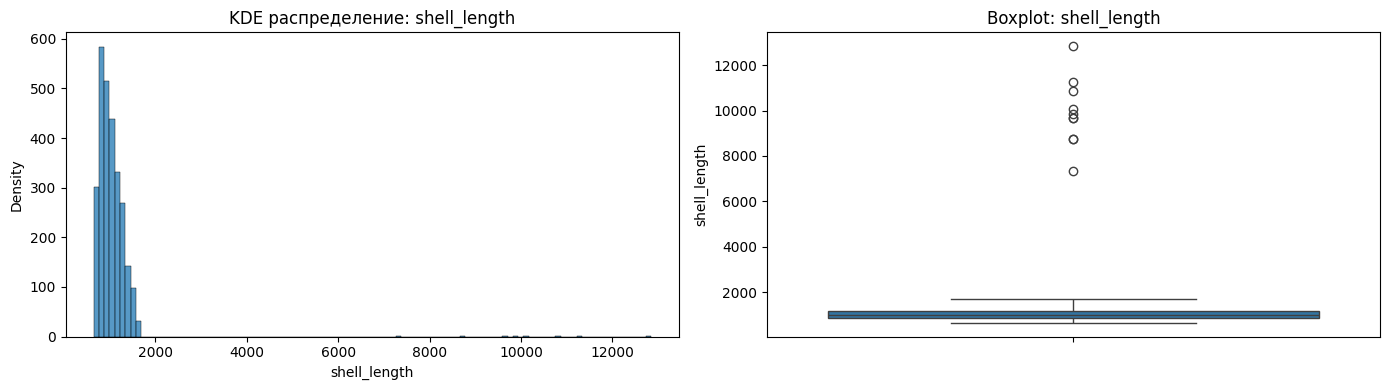

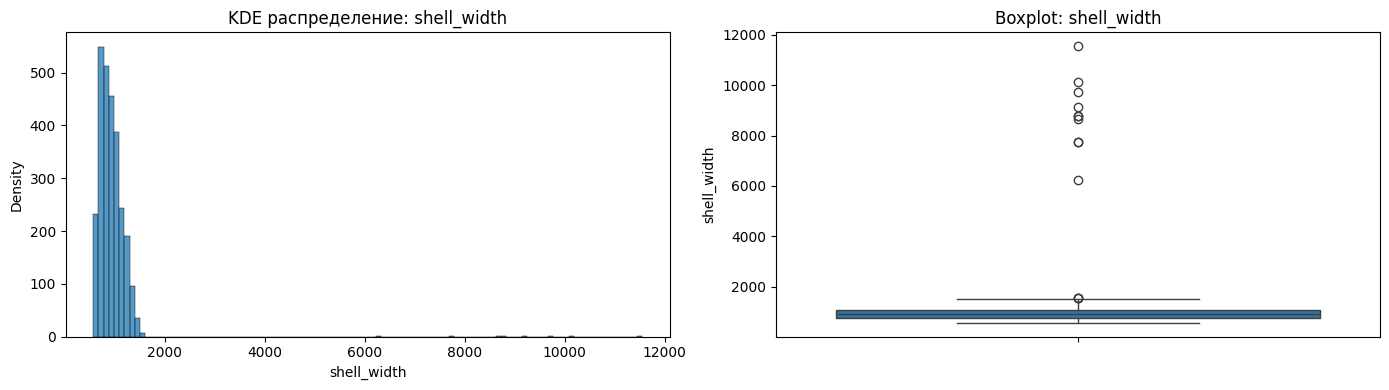

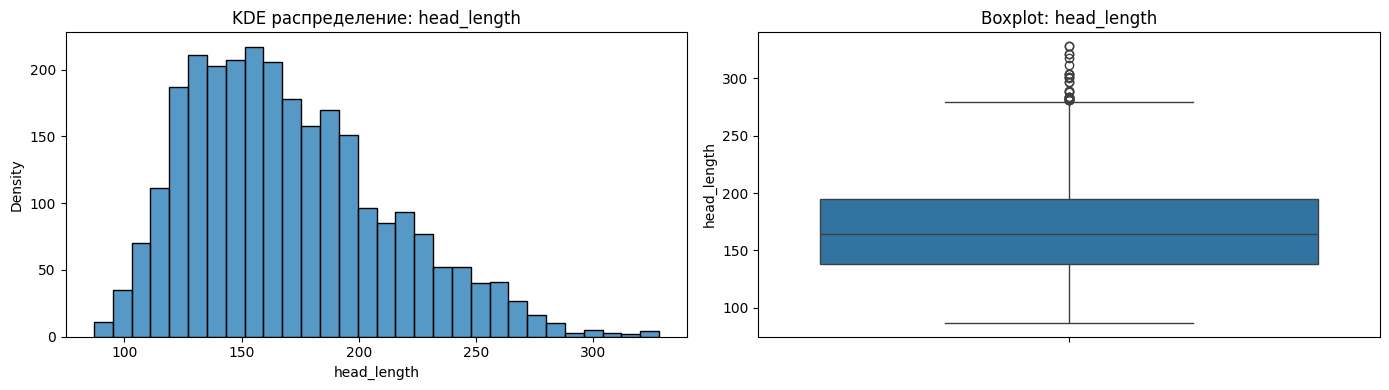

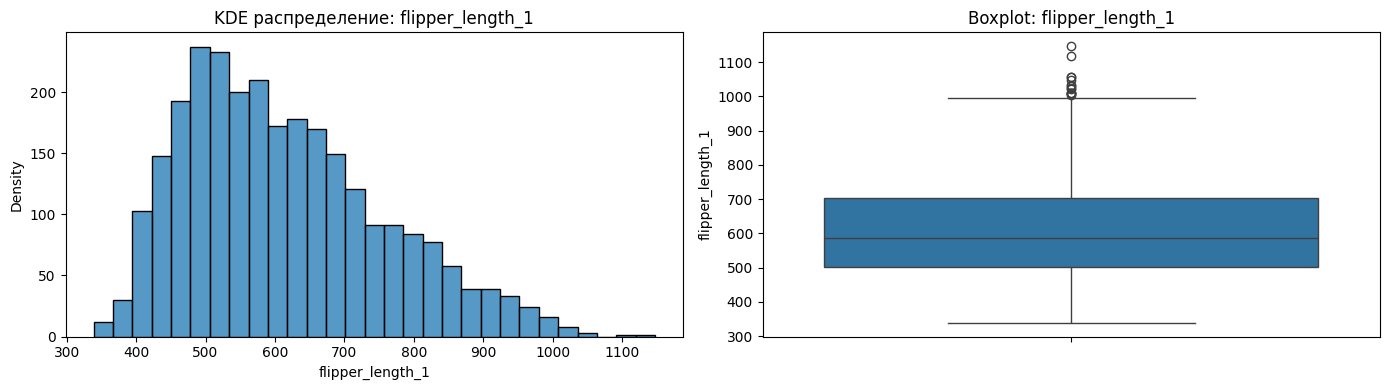

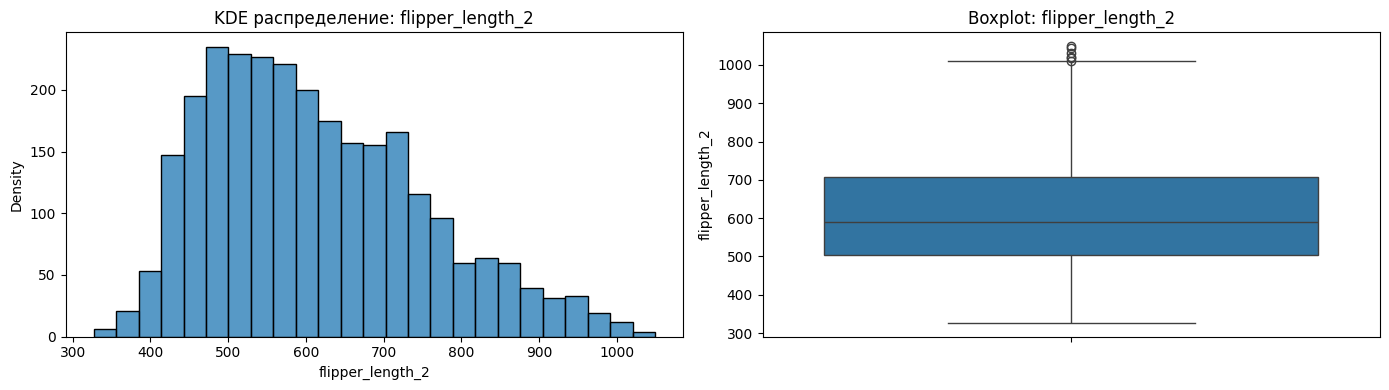

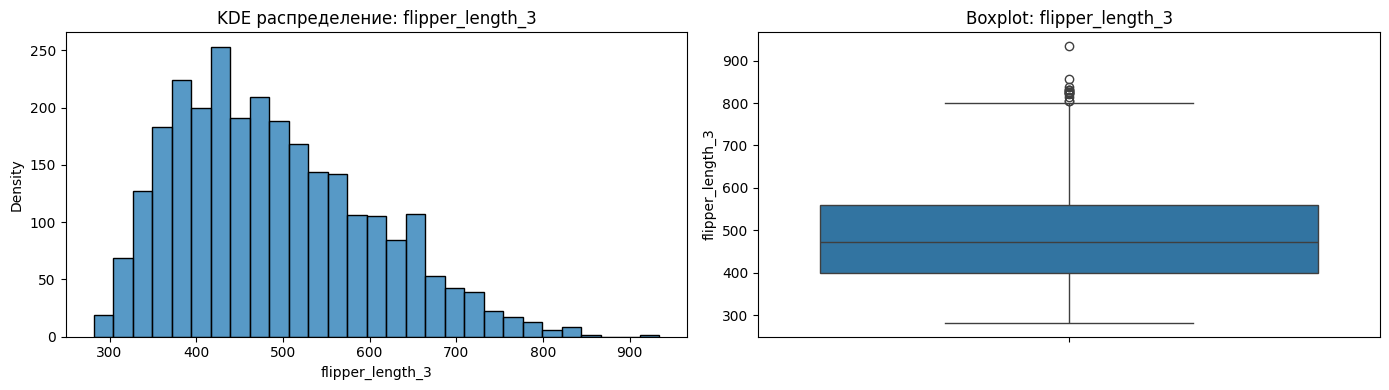

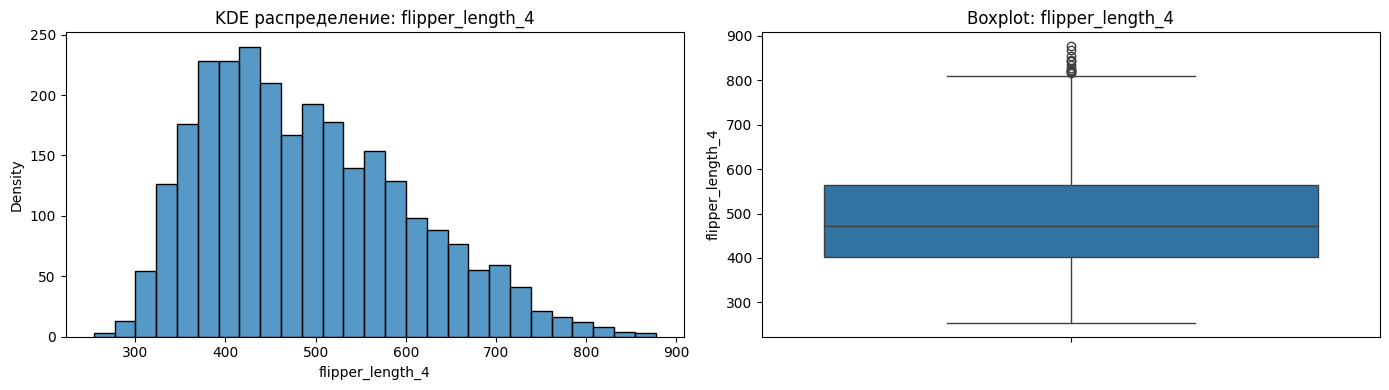

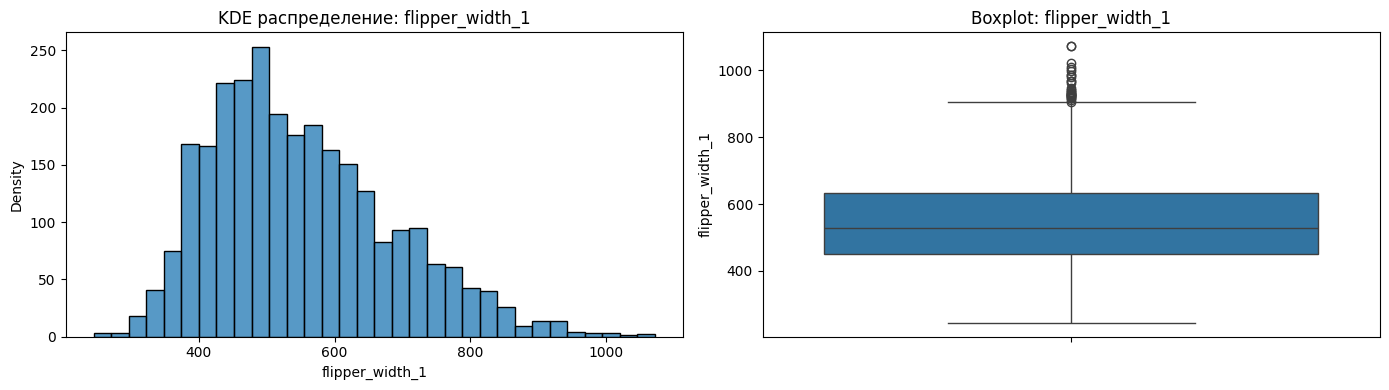

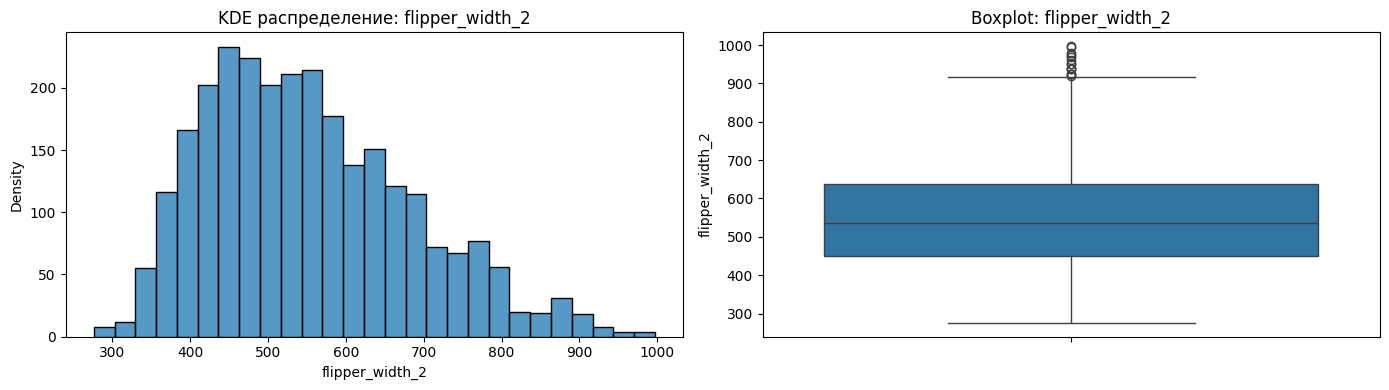

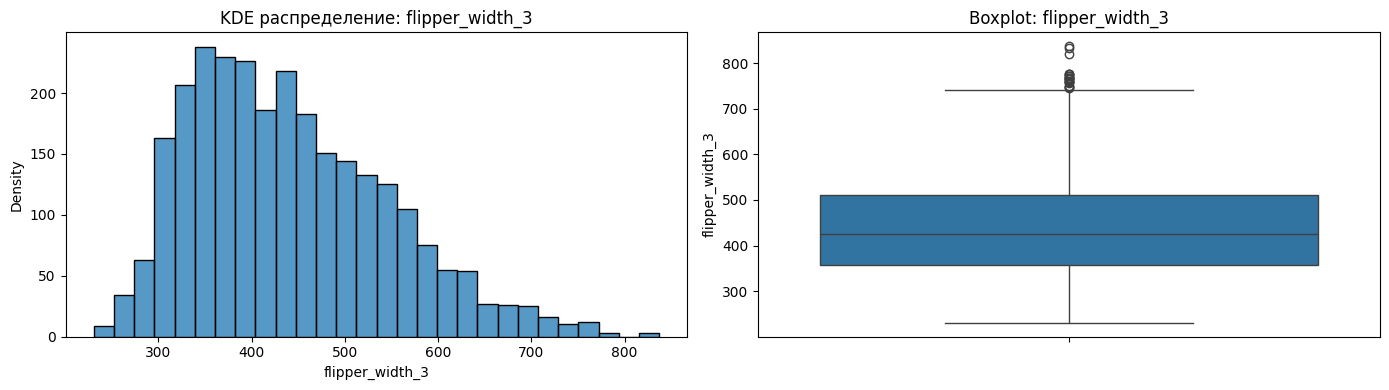

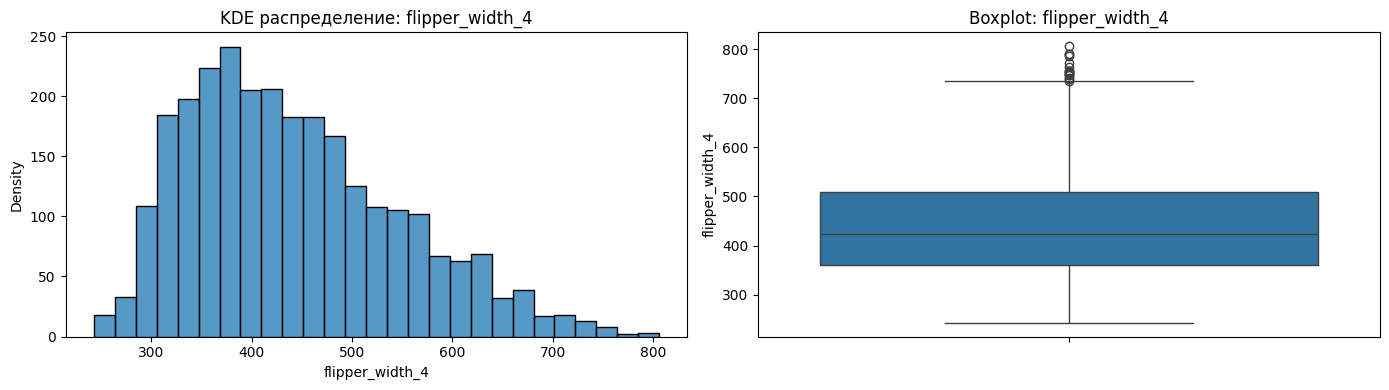

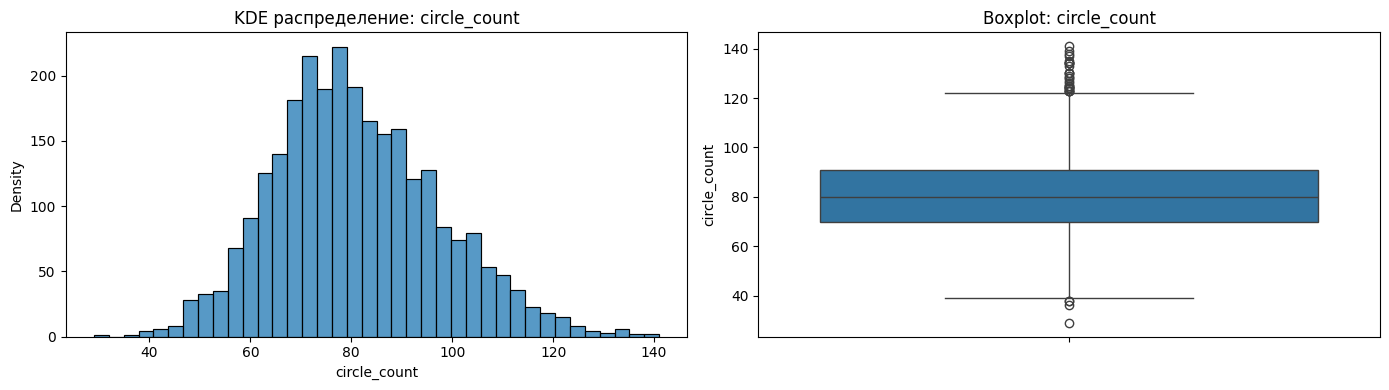

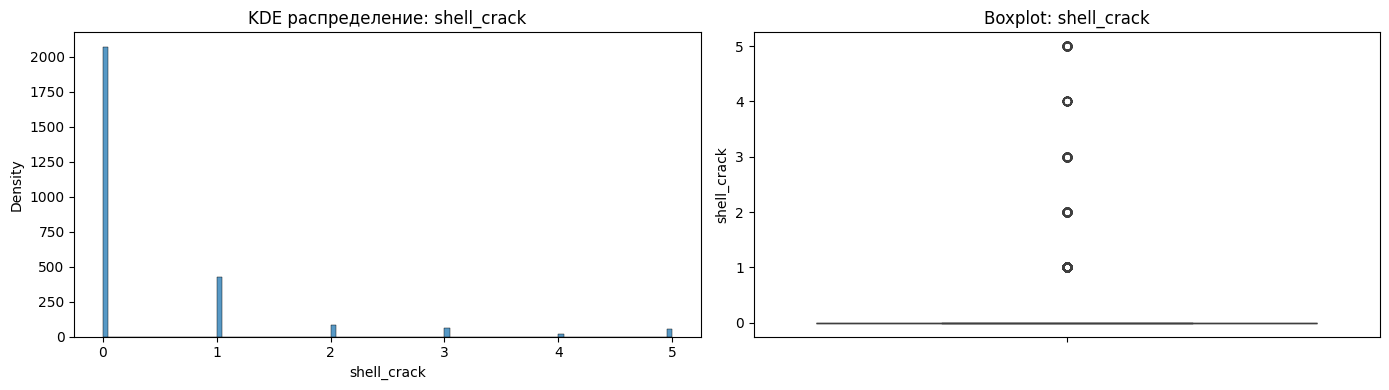

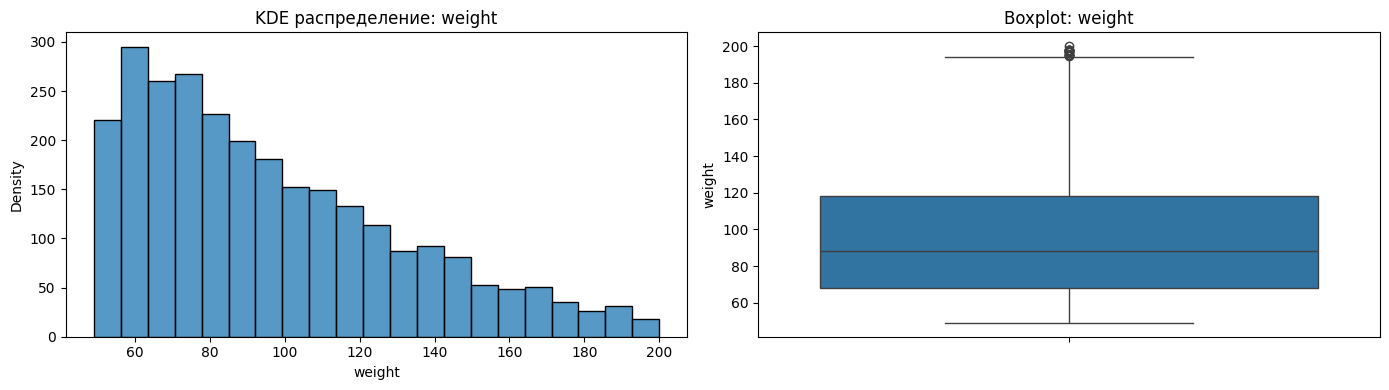

In [24]:
## Выводим boxplot и распределение числовых колонок
plot_numeric_kde_box(
    df,
    num_cols
)

Видны очень большие выбросы на размерах раковин. Но мы знаем что в этих данных есть ошибка.
По графикам виден явный разрыв после 2000. Можно все значения больше 2000 разделим на 10


In [25]:
# 1. Создаем функцию с понятным названием
def correct_length(length):
    """
    Делит длину на 10, если она >= 2000.
    Остальные значения оставляет без изменений.
    """
    if length >= 2000:
        return length / 10
    return length

# 2. Применяем её к столбцу через .apply()
df['shell_length'] = df['shell_length'].apply(correct_length)
df['shell_width'] = df['shell_width'].apply(correct_length)

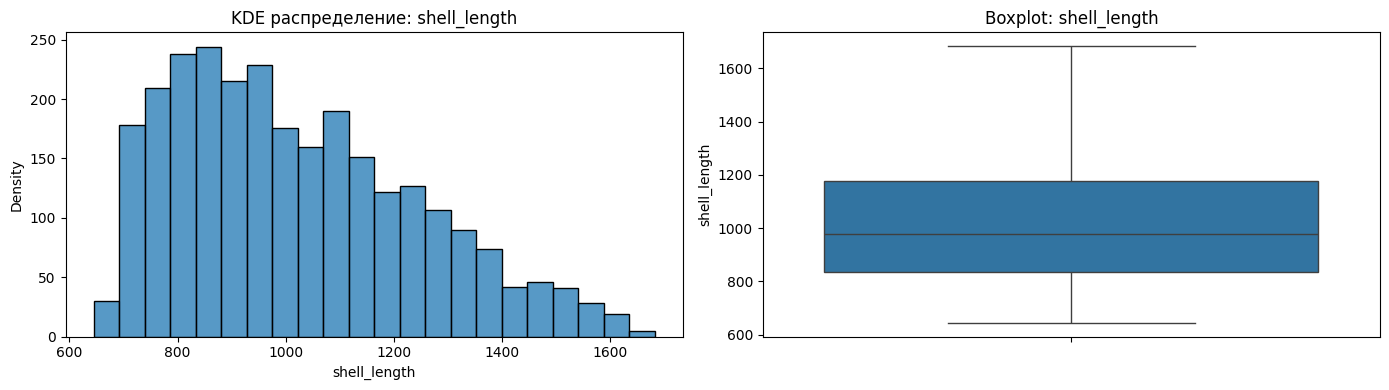

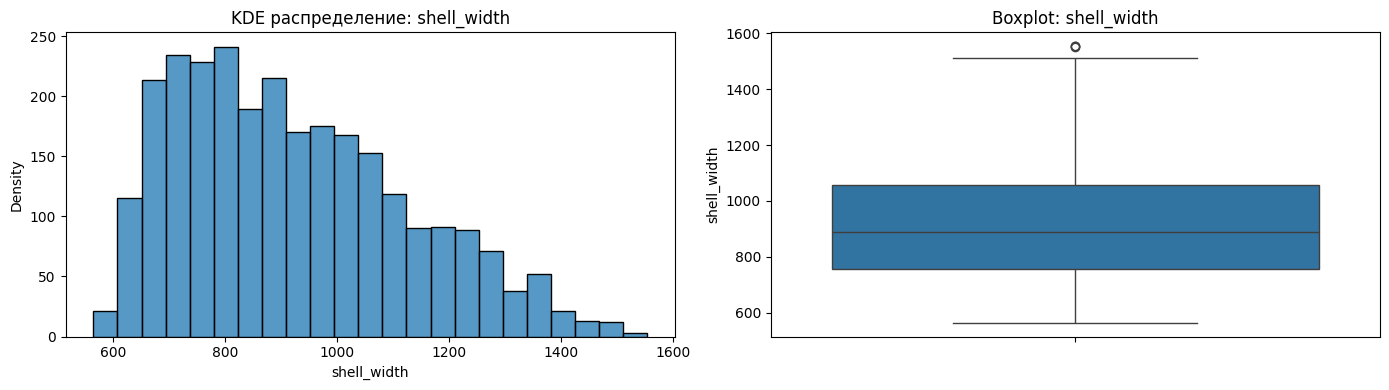

In [26]:
# Повторим распределение
# Выводим boxplot и распределение числовых колонок
plot_numeric_kde_box(
    df,
    ['shell_length', 'shell_width']
)

Распределение выровнялось, поэтому оставим без удаления выбросов

In [27]:
df.sample(5, random_state=42)

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
3532,1538.0,1263.0,235.0,303.0,868,746,914,744,815.0,644.0,702.0,598.0,121,0.0,180.375
1296,1346.0,1247.0,211.0,238.0,893,819,876,708,671.0,637.0,719.0,564.0,108,4.0,147.527
8173,865.0,727.0,146.0,150.0,546,434,507,535,457.0,376.0,411.0,350.0,72,1.0,73.508
7546,877.0,795.0,153.0,160.0,519,441,530,493,423.0,443.0,403.0,391.0,70,0.0,68.828
4201,823.0,775.0,148.0,170.0,508,477,470,474,405.0,354.0,383.0,353.0,71,1.0,73.453


In [28]:
# Меняем тип данных с помощью цикла
for column in ['shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'shell_crack']:
    df[column] = pd.to_numeric(df[column], errors='coerce', downcast='integer') 

In [29]:
df.info()

<class 'pandas.DataFrame'>
Index: 2721 entries, 8 to 8859
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2721 non-null   int16  
 1   shell_width       2721 non-null   float64
 2   head_length       2721 non-null   int16  
 3   head_width        2721 non-null   int16  
 4   flipper_length_1  2721 non-null   int64  
 5   flipper_width_1   2721 non-null   int64  
 6   flipper_length_2  2721 non-null   int64  
 7   flipper_width_2   2721 non-null   int64  
 8   flipper_length_3  2721 non-null   int16  
 9   flipper_width_3   2721 non-null   int16  
 10  flipper_length_4  2721 non-null   int16  
 11  flipper_width_4   2721 non-null   int16  
 12  circle_count      2721 non-null   int16  
 13  shell_crack       2721 non-null   int8   
 14  weight            2721 non-null   float64
dtypes: float64(2), int16(8), int64(4), int8(1)
memory usage: 194.0 KB


In [30]:
df.shape[0]

2721

In [31]:
## Какой % от df остался
df_left = 100 - df.shape[0] / start_df_size  * 100
print(f"% Удаленных значений из-за пропусков: {df_left:.2f}%")

% Удаленных значений из-за пропусков: 3.82%


### Изучение корреляции между данными

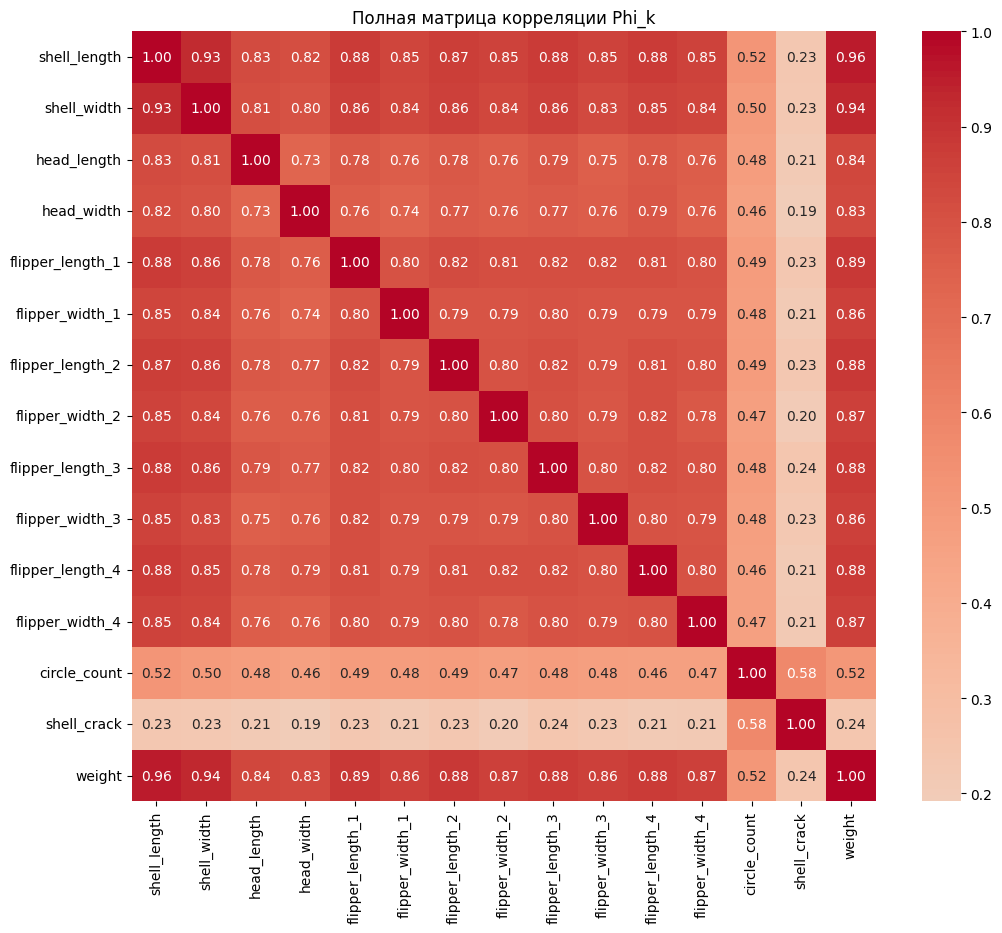

In [35]:
# 1. Строим тепловую карту для всей матрицы
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Полная матрица корреляции Phi_k')
plt.show()

### Итоги предобработки данных

Общий размер изначальных данных: 8861 наблюдений

Колонка `registration number` переименована в `registration_number`, чтобы соответствовать ожидаемым данных и общему принципу наименования.

В названии категорий были выявлены дубликаты. И приведены к нижнему регистру. После приведения названий видов к нижнему регистру и фильтрации по нужному в задании типу черепах `Chelonia mydas`, Датасет составил `2829 налюдений`

Из данных были удалены столюца, которые не являются признаками черепахи:

- `id` - индекс записи
- `binomial_name` - у нас только один binomial_name, и в данные мы должны передать числа.
- `registration_number` - уникальный номер черепахи, не относится к ее размеру/возасту и т.д
- `measure_count` - количество измерений, скорее свидетельствуют о точности данных по черепахе
- `timestamp` - время измерения, относится к измерению, но не к характеристикам черепахи

В количественных данных были видны большие выбросы на размерах раковин. Но мы знаем что в этих данных есть ошибка. По графикам распределения виден явный разрыв после 2000. Поэтому все значения более 2000 были разделены на 10. После этого распределение выровнялось.

- `shell_crack` - большое количество пропусков `76%` - заменены на 0, потому что в данных минимальное значение было 1. Но стоит помнить об этом, потому что NaN могло означать как "нет трещин", так и "осмотр не прововдился"
- `width` - удалены значения равные 0, поскольку это наша целевая переменная. Мы по ней обучаем и тестируем. Мне кажется нельзя заполнять никакими значениями

Итоговый размер выборки составил `2721 наблюдения`, Пропусками удалено `3.82%` значений 

Анализ корелляции показал, что все признаки сильно кореллируют друг с другом. Что логично - черепаха растет целиков, и вместе с ней растут лапы, голова и панцирь. При обучении модели нужно быть особенно осторожными с мультиколлениарностью, поскольку 4 лапы - это практически 1 признак. Возможно стоит больше узнать о черепахах и вделать 2 колонки - передние и задние лапы, или 1 колонку - лапа. 



## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.